In [2]:
import pypsa
import matplotlib.pyplot as plt
import pandas as pd

network_2011 = pypsa.Network("../saved/2011/elec_s_10_ec_lcopt_Co2L-3h.nc")
network_2013 = pypsa.Network("../saved/2013/elec_s_10_ec_lcopt_Co2L-3h.nc")
network_2018 = pypsa.Network("../saved/2018/elec_s_10_ec_lcopt_Co2L-3h.nc")

singapore = pypsa.Network("../results/networks/elec_s_10_ec_lcopt_Co2L-3h.nc") #this is still 2018 rn

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [5]:
from formatiser import ember_to_custom

df = pd.read_csv("ember-United\ Kingdom.csv")
daily_df = ember_to_custom(df)
print(daily_df)

<>:3: DeprecationWarning: invalid escape sequence '\ '
<>:3: DeprecationWarning: invalid escape sequence '\ '
/tmp/ipykernel_5988/2190845475.py:3: DeprecationWarning: invalid escape sequence '\ '
  df = pd.read_csv("ember-United\ Kingdom.csv")
/tmp/ipykernel_5988/2190845475.py:3: DeprecationWarning: invalid escape sequence '\ '
  df = pd.read_csv("ember-United\ Kingdom.csv")


ImportError: cannot import name 'ember_to_custom' from 'formatiser' (/home/shotton/pypsa-earth/shotton/formatiser.py)

In [4]:
demand_data_sg = singapore.loads_t.p
total_demand_sg = demand_data_sg.sum(axis=1)

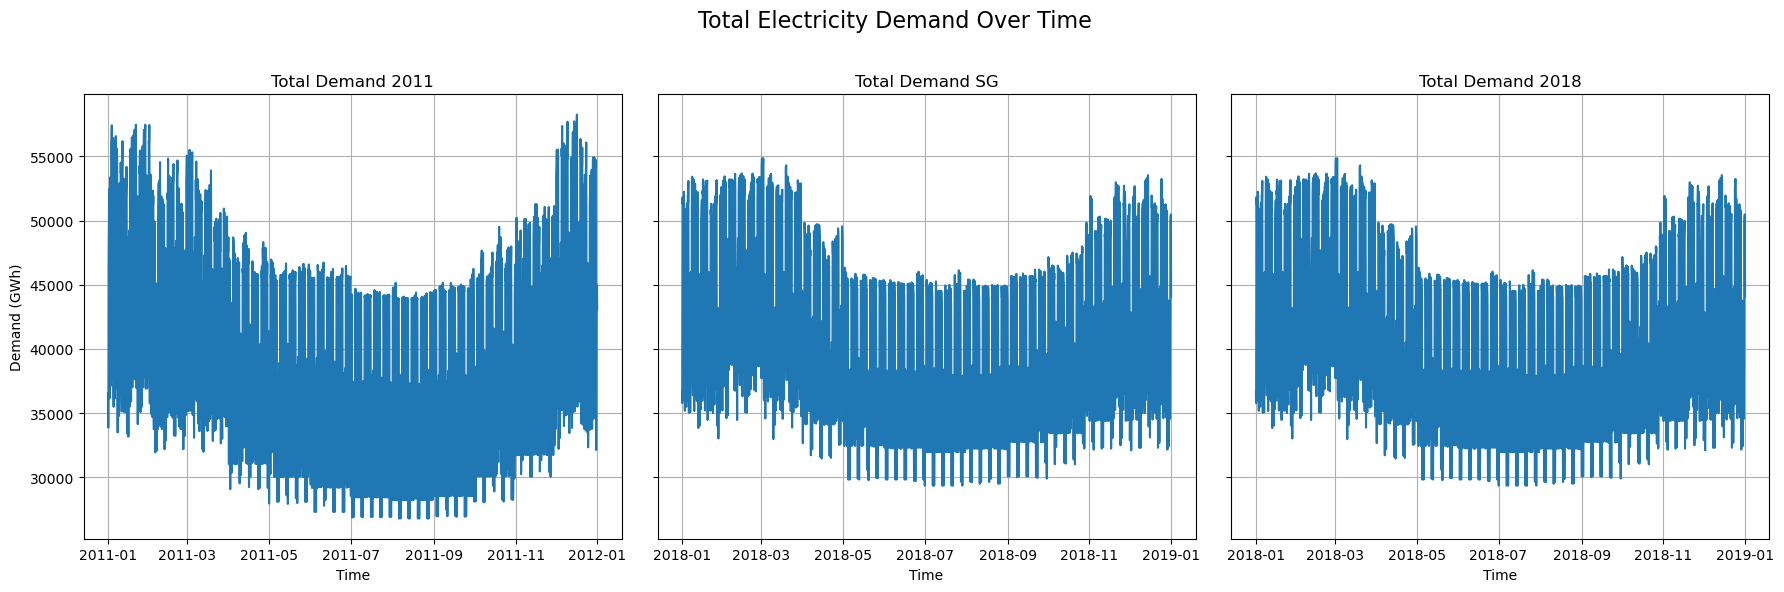

In [ ]:
# Calculate total demand across all buses for each time step
demand_data_2011 = network_2011.loads_t.p
total_demand_2011 = demand_data_2011.sum(axis=1)
demand_data_2013 = network_2013.loads_t.p
total_demand_2013 = demand_data_2013.sum(axis=1)
demand_data_2018 = network_2018.loads_t.p
total_demand_2018 = demand_data_2018.sum(axis=1)

# Create figure and 3 subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Plot each demand series on its own subplot
axes[0].plot(total_demand_2011)
axes[0].set_title('Total Demand 2011')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Demand (GWh)')
axes[0].grid(True)

axes[1].plot(total_demand_2013)
axes[1].set_title('Total Demand 2013')
axes[1].set_xlabel('Time')
axes[1].grid(True)

axes[2].plot(total_demand_2018)
axes[2].set_title('Total Demand 2018')
axes[2].set_xlabel('Time')
axes[2].grid(True)

fig.suptitle('Total Electricity Demand Over Time', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()


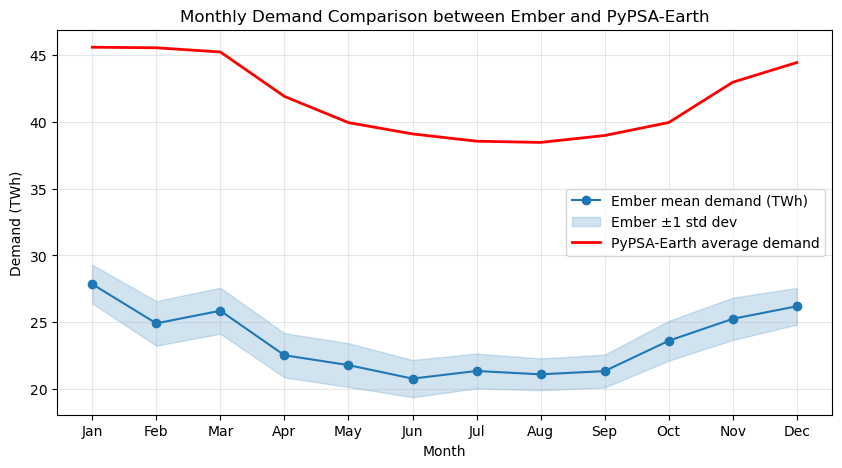

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

rolling_window = 5 * 8  # 5 days × 8 points/day

# Remove years but keep month/day/hour information
def remove_year(series):
    return pd.Series(
        series.values,
        index=series.index.map(lambda x: x.replace(year=2000))
    )

# Convert each series to same year and calculate rolling means
total_demand_2011_adj = remove_year(total_demand_2011)
total_demand_2013_adj = remove_year(total_demand_2013)
total_demand_2018_adj = remove_year(total_demand_2018)

# Calculate average across all three years
average_demand = (total_demand_2011_adj + total_demand_2013_adj + total_demand_2018_adj) / 3000
average_demand_rolling = average_demand.rolling(window=rolling_window).mean()

# Process Ember data
ember = pd.read_csv("ember-United Kingdom.csv")
ember['date_dt'] = pd.to_datetime(ember['date'], format='%Y-%m')
ember['month'] = ember['date_dt'].dt.month
gen_monthly_stats = ember.groupby('month')['demand_twh'].agg(['mean','std']).reindex(range(1,13))
month_names = pd.to_datetime(gen_monthly_stats.index.astype(str), format='%m').strftime('%b')

# Plot
plt.figure(figsize=(10,5))
x = gen_monthly_stats.index

# Plot Ember data
plt.plot(x, gen_monthly_stats['mean'], marker='o', label='Ember mean demand (TWh)', color='C0')
plt.fill_between(x,
                 gen_monthly_stats['mean'] - gen_monthly_stats['std'],
                 gen_monthly_stats['mean'] + gen_monthly_stats['std'],
                 color='C0', alpha=0.2, label='Ember ±1 std dev')

# Plot PyPSA average demand
# Convert to monthly averages for comparison
monthly_avg = average_demand_rolling.groupby([average_demand_rolling.index.month]).mean()
plt.plot(monthly_avg.index, monthly_avg.values, 
         label='PyPSA-Earth average demand', color='red', linewidth=2)

plt.xticks(x, month_names)
plt.xlabel('Month')
plt.ylabel('Demand (TWh)')
plt.title('Monthly Demand Comparison between Ember and PyPSA-Earth')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

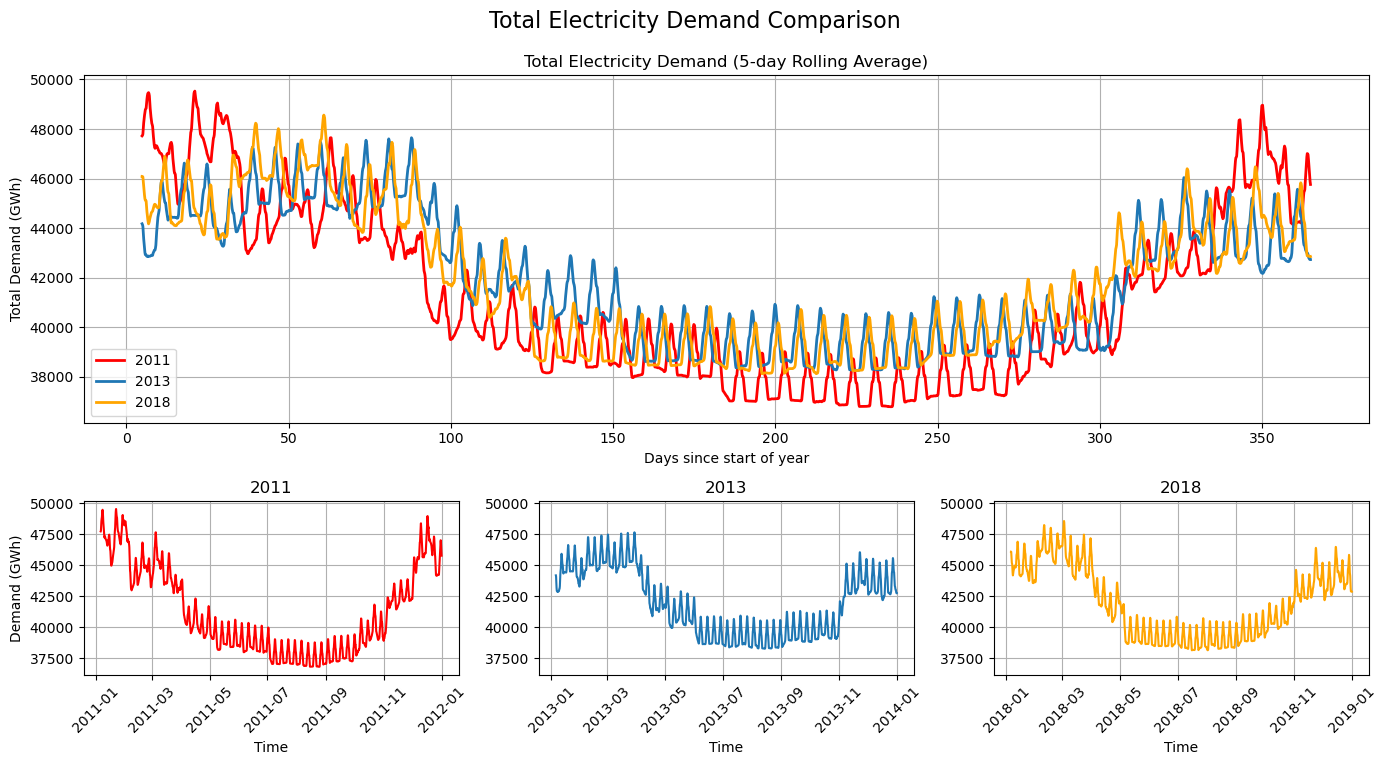

In [48]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

rolling_window = 5 * 8  # 5 days × 8 points/day
total_demand_2011_rolling = total_demand_2011.rolling(window=rolling_window).mean()
total_demand_2013_rolling = total_demand_2013.rolling(window=rolling_window).mean()
total_demand_2018_rolling = total_demand_2018.rolling(window=rolling_window).mean()

def relative_days(series):
    start = series.index[0]
    return (series.index - start).total_seconds() / (24 * 3600)  # seconds → days

# Compute relative x-values
x_2011 = relative_days(total_demand_2011_rolling)
x_2013 = relative_days(total_demand_2013_rolling)
x_2018 = relative_days(total_demand_2018_rolling)

# --- Create flexible layout ---
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, height_ratios=[2, 1])  # 2 rows, 3 cols; top row twice as tall

# --- Top plot (spans all 3 columns) ---
ax_top = fig.add_subplot(gs[0, :])  # span entire top row
ax_top.plot(x_2011, total_demand_2011_rolling, label='2011', color='red', linewidth=2)
ax_top.plot(x_2013, total_demand_2013_rolling, label='2013', linewidth=2)
ax_top.plot(x_2018, total_demand_2018_rolling, label='2018', color='orange', linewidth=2)
ax_top.legend()
ax_top.set_xlabel('Days since start of year')
ax_top.set_ylabel('Total Demand (GWh)')
ax_top.set_title('Total Electricity Demand (5-day Rolling Average)')
ax_top.grid(True)

# --- Bottom row (3 equal subplots) ---
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[1, 2], sharey=ax1)

# Plot individual years
ax1.plot(total_demand_2011_rolling, color='r')
ax1.set_title('2011')
ax1.set_xlabel('Time')
ax1.set_ylabel('Demand (GWh)')
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid(True)

ax2.plot(total_demand_2013_rolling)
ax2.set_title('2013')
ax2.set_xlabel('Time')
ax2.tick_params(axis='x', labelrotation=45)
ax2.grid(True)

ax3.plot(total_demand_2018_rolling, color='orange')
ax3.set_title('2018')
ax3.set_xlabel('Time')
ax3.tick_params(axis='x', labelrotation=45)
ax3.grid(True)

fig.suptitle('Total Electricity Demand Comparison', fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


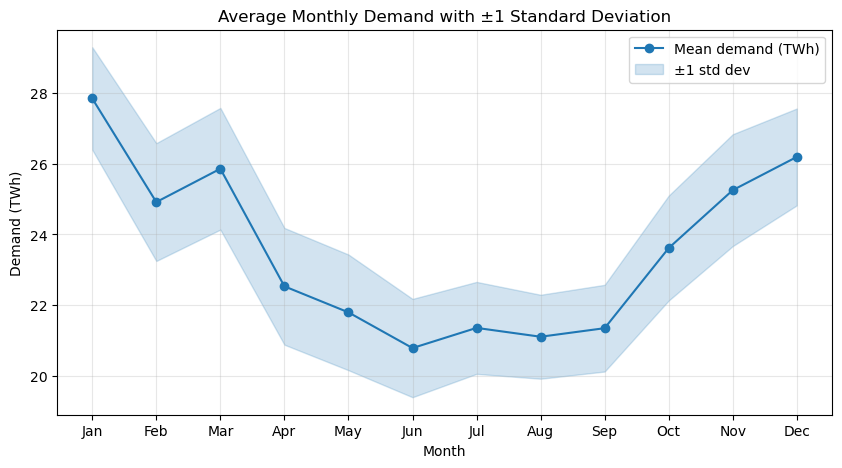

In [34]:
ember = pd.read_csv("ember-United Kingdom.csv")

ember['date_dt'] = pd.to_datetime(ember['date'], format='%Y-%m')
ember['month'] = ember['date_dt'].dt.month

gen_monthly_stats = ember.groupby('month')['demand_twh'].agg(['mean','std']).reindex(range(1,13))

month_names = pd.to_datetime(gen_monthly_stats.index.astype(str), format='%m').strftime('%b')

plt.figure(figsize=(10,5))
x = gen_monthly_stats.index
plt.plot(x, gen_monthly_stats['mean'], marker='o', label='Mean demand (TWh)', color='C0')
plt.fill_between(x,
				 gen_monthly_stats['mean'] - gen_monthly_stats['std'],
				 gen_monthly_stats['mean'] + gen_monthly_stats['std'],
				 color='C0', alpha=0.2, label='±1 std dev')
plt.xticks(x, month_names)
plt.xlabel('Month')
plt.ylabel('Demand (TWh)')
plt.title('Average Monthly Demand with ±1 Standard Deviation')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import geopandas as gpd
import xarray as xr
import atlite
import yaml

# -----------------------
# Load config
# -----------------------
with open("../config.yaml") as f:
    config = yaml.safe_load(f)

# -----------------------
# Load regions
# -----------------------
regions = gpd.read_file("../resources/bus_regions/regions_onshore.geojson").set_index("name")

# -----------------------
# Load cutout
# -----------------------
cutout = atlite.Cutout("../cutouts/cutout-2018-era5.nc")

# -----------------------
# Build solar excluder (same as PyPSA-Earth)
# -----------------------
excluder = atlite.ExclusionContainer()

# -----------------------
# Compute availability matrix
# -----------------------
availability = cutout.availabilitymatrix(
    regions,
    excluder,
)

availability

<xarray.DataArray (name: 1176, y: 58, x: 65)> Size: 35MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * name     (name) object 9kB '0' '2' '5' '7' ... '1570' '1571' '1572' '1573'
  * y        (y) float64 464B 47.1 47.4 47.7 48.0 48.3 ... 63.3 63.6 63.9 64.2
  * x        (x) float64 520B -15.3 -15.0 -14.7 -14.4 -14.1 ... 3.0 3.3 3.6 3.9

In [19]:
availability = xr.open_dataarray('solar_layout_uk.nc')
availability 

<xarray.DataArray 'capacity' (y: 58, x: 65)> Size: 30kB
[3770 values with dtype=float64]
Coordinates:
  * y        (y) float64 464B 47.1 47.4 47.7 48.0 48.3 ... 63.3 63.6 63.9 64.2
  * x        (x) float64 520B -15.3 -15.0 -14.7 -14.4 -14.1 ... 3.0 3.3 3.6 3.9

/home/shotton/miniforge3/envs/pypsa-earth/lib/python3.11/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'gadm41_GBR.gpkg': 'ADM_ADM_0' (default), 'ADM_ADM_1', 'ADM_ADM_2', 'ADM_ADM_3', 'ADM_ADM_4'. Specify layer parameter to avoid this warning.
  result = read_func(


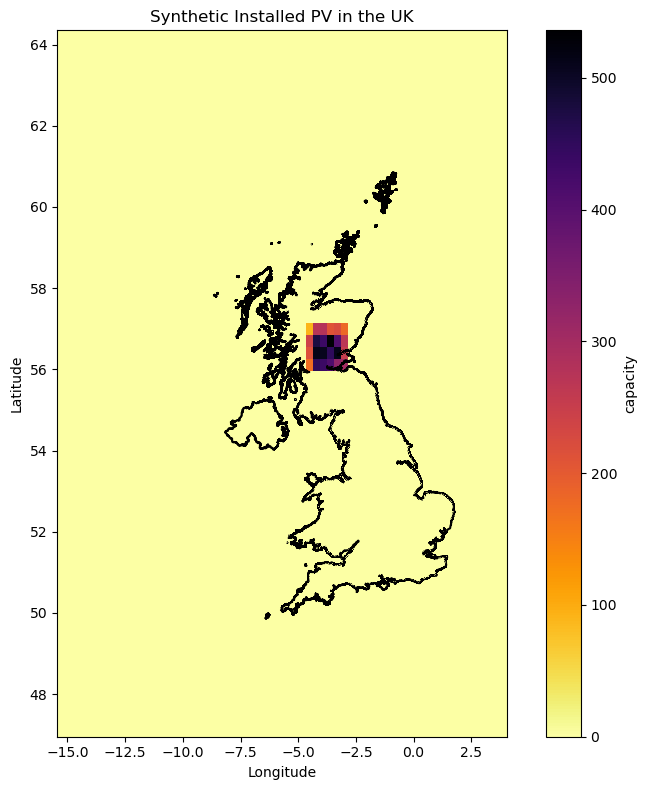

In [29]:
import numpy as np
import pandas as pd

def load_uk_capacities(
    typ="Solarstrom",
    n_installations=2000,
    total_capacity_mw=15000,
    until="2012-01-01",
    seed=42,
):
    """
    Synthetic  solar register for the UK.
    """

    rng = np.random.default_rng(seed)

    # Rough UK bounding box (WGS84)
    lon_min, lon_max = -4.5, -3.0
    lat_min, lat_max = 56, 57

    lons = rng.uniform(lon_min, lon_max, n_installations)
    lats = rng.uniform(lat_min, lat_max, n_installations)

    # Capacity distribution (MW)
    raw_caps = rng.lognormal(mean=1.2, sigma=0.7, size=n_installations)
    capacities = raw_caps / raw_caps.sum() * total_capacity_mw

    installation_dates = pd.to_datetime(
        rng.integers(
            pd.Timestamp("2000-01-01").value,
            pd.Timestamp("2022-01-01").value,
            n_installations,
        )
    )

    data = pd.DataFrame(
        {
            "x": lons,
            "y": lats,
            "capacity": capacities,
            "installation_date": installation_dates,
            "type": typ,
            "validation": "OK",
        }
    )

    if until is not None:
        data = data[data["installation_date"] < pd.to_datetime(until)]

    return data


capacities = load_uk_capacities(until="2012")

solar_layout = cutout.layout_from_capacity_list(
    capacities,
    col="capacity",
)

import geopandas as gpd

uk_shapefile_path = "../data/gadm/gadm41_GBR/gadm41_GBR.gpkg"
uk = gpd.read_file(uk_shapefile_path)



import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

# Base raster: installed solar layout
solar_layout.plot(
    ax=ax,
    cmap="inferno_r",
    add_colorbar=True,
)

# UK outline overlay
uk.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5,
)

ax.set_title("Synthetic Installed PV in the UK")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

# save solar_layout
solar_layout.to_netcdf("solar_layout_uk.nc")


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/home/shotton/miniforge3/envs/pypsa-earth/lib/python3.11/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401
/home/shotton/miniforge3/envs/pypsa-earth/lib/python3.11/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'gadm41_GBR.gpkg': 'ADM_ADM_0' (default), 'ADM_ADM_1', 'ADM_ADM_2', 'ADM_ADM_3', 'ADM_ADM_4'. Specify layer parameter to avoid this warning.
  result = read_func(


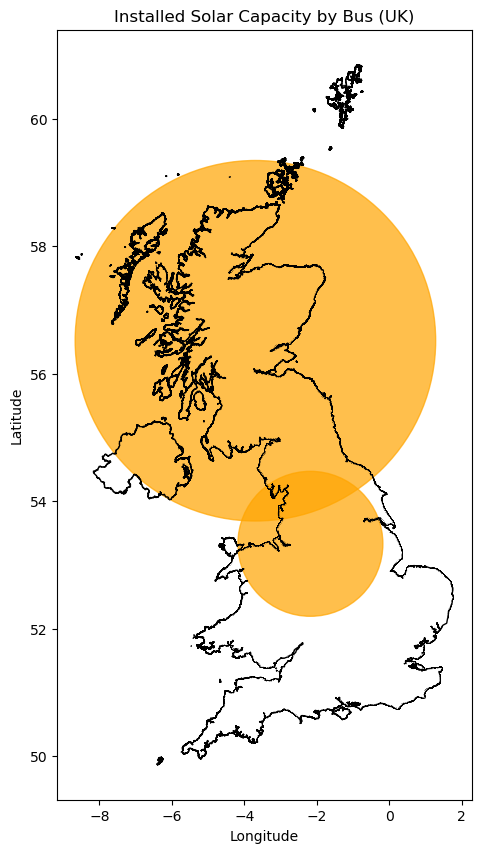

In [1]:
import pypsa
import matplotlib.pyplot as plt
import geopandas as gpd

# Load network
n = pypsa.Network("../results/networks/elec_s_10_ec_lcopt_Co2L-3h.nc")

# Select solar generators
solar = n.generators[n.generators.carrier == "solar"]

# Sum capacity per bus
solar_cap = solar.groupby("bus").p_nom.sum()

# Join with bus coordinates
buses = n.buses.loc[solar_cap.index]

# Load UK outline
uk = gpd.read_file("../data/gadm/gadm41_GBR/gadm41_GBR.gpkg")
uk = uk.to_crs("EPSG:4326")  # make sure CRS matches bus coordinates

fig, ax = plt.subplots(figsize=(8, 10))

# Plot UK outline
uk.boundary.plot(ax=ax, color="black", linewidth=1)

# Plot bus capacities
buses.plot(
    ax=ax,
    kind="scatter",
    x="x",
    y="y",
    s=solar_cap * 5,   # scale marker size
    alpha=0.7,
    color="orange",
)

ax.set_title("Installed Solar Capacity by Bus (UK)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()



In [6]:
n = pypsa.Network("../saved/2018/elec_s_10_ec_lcopt_Co2L-3h.nc")

renewables = n.generators.index[
    n.generators.carrier.isin(["onwind", "offwind", "solar"])
]

baseline = n.copy()
perturbed = n.copy()
perturbed.generators_t.p_max_pu[renewables] *= 1.10
perturbed.optimize()


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 14/14 [00:00<00:00, 16.22it/s]
INFO:linopy.io: Writing time: 6.41s


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-6e2lomq9 has 1153540 rows; 557826 cols; 2184889 nonzeros
Coefficient ranges:
  Matrix [1e-02, 4e+01]
  Cost   [3e-02, 3e+05]
  Bound  [3e+00, 7e+09]
  RHS    [4e-03, 8e+07]
Presolving model
423991 rows, 445285 cols, 1307779 nonzeros  0s
355171 rows, 376465 cols, 1195253 nonzeros  1s
Dependent equations search running on 88860 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.02s (limit = 1000.00s)
355171 rows, 376465 cols, 1195253 nonzeros  2s
Presolve : Reductions: rows 355171(-798369); columns 376465(-181361); elements 1195253(-989636)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -2.6374630516e+05 Ph1: 125774(1.13905e+08); Du: 23376(395.541) 3s
      50744     1.7097182087e+08 Pr: 20611(2.11302e+08); Du: 0(3.07337e-07) 8s
      57058     2

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 557826 primals, 1153540 duals
Objective: 7.12e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

In [8]:
def total_generation(n):
    return n.generators_t.p.sum().sum()

def total_curtailment(n):
    available = (
        n.generators_t.p_max_pu.mul(n.generators.p_nom, axis=1)
    ).sum().sum()

    dispatched = n.generators_t.p.sum().sum()

    return available - dispatched

def total_storage_absorption(n):
    if n.storage_units.empty:
        return 0.0
    return n.storage_units_t.p.clip(lower=0).sum().sum()

def total_net_exports(n):
    exports = 0.0

    if not n.lines.empty:
        exports += n.lines_t.p0.sum().sum()

    if not n.links.empty:
        exports += n.links_t.p0.sum().sum()

    return exports

def total_available_energy(n, gens):
    return (
        n.generators_t.p_max_pu.loc[:, gens]
        .mul(n.generators.loc[gens, "p_nom"], axis=1)
        .sum()
        .sum()
    )

E_avail_base = total_available_energy(baseline, renewables)
def total_generation_subset(n, gens):
    return n.generators_t.p.loc[:, gens].sum().sum()

E_gen_base = total_generation_subset(baseline, renewables)

ΔE_gen = total_generation(perturbed) - total_generation(baseline)
ΔE_curt = total_curtailment(perturbed) - total_curtailment(baseline)
ΔE_store = total_storage_absorption(perturbed) - total_storage_absorption(baseline)
ΔE_exp = total_net_exports(perturbed) - total_net_exports(baseline)
surplus_fraction_avail = ΔE_curt / (0.10 * E_avail_base)

residual = ΔE_gen - (ΔE_curt + ΔE_store + ΔE_exp)

print("=== ENERGY BALANCE TEST ===")
print(f"Δ Generation      : {ΔE_gen:.3e} MWh")
print(f"Δ Curtailment     : {ΔE_curt:.3e} MWh")
print(f"Δ Storage charge  : {ΔE_store:.3e} MWh")
print(f"Δ Net exports     : {ΔE_exp:.3e} MWh")
print("------------------------------")
print(f"Residual          : {residual:.3e} MWh")
print(f"Surplus / (10% avail)        : {surplus_fraction_avail:.3f}")

=== ENERGY BALANCE TEST ===
Δ Generation      : -8.132e+04 MWh
Δ Curtailment     : 2.211e+06 MWh
Δ Storage charge  : 1.998e+01 MWh
Δ Net exports     : -1.187e+06 MWh
------------------------------
Residual          : -1.105e+06 MWh
Surplus / (10% avail)        : 1.038
